# Dependency

In [ ]:
import pickle
import math, os, gc, warnings, argparse, glob, random, shutil
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Sampler, Dataset as TorchDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from einops import rearrange
from einops.layers.torch import Rearrange
from timm.models.layers import trunc_normal_
from torch.backends import cudnn
import shutil
from google.colab import drive

warnings.filterwarnings('ignore')

# ────────────────────────────────────────────────────────────────────────────
# Phoneme vocabulary
# ────────────────────────────────────────────────────────────────────────────
LOGIT_TO_PHONEME = [
    'BLANK',
    'AA', 'AE', 'AH', 'AO', 'AW', 'AY', 'B',  'CH', 'D',  'DH',
    'EH', 'ER', 'EY', 'F',  'G',  'HH', 'IH', 'IY', 'JH', 'K',
    'L',  'M',  'N',  'NG', 'OW', 'OY', 'P',  'R',  'S',  'SH',
    'T',  'TH', 'UH', 'UW', 'V',  'W',  'Y',  'Z',  'ZH', '|',
]
NUM_PHONEMES = len(LOGIT_TO_PHONEME)   # 41

cudnn.benchmark    = False
cudnn.deterministic = True

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


# data preparation

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# DATA PIPELINE  (ported from EEGConformer)
# ════════════════════════════════════════════════════════════════════════════

def load_h5py_file(file_path: str) -> dict:
    """
    Load a single .hdf5 session file.

    Stores each trial's features as-is (T, 512) — no global padding here.
    The Dataset class handles clipping/padding lazily at __getitem__ time.

    Returns
    -------
    dict with keys:
        neural_features : list of np.ndarray (T_i, 512)
        n_time_steps    : list of int
        seq_class_ids   : list of np.ndarray (max_seq,)
        seq_len         : list of int
        transcriptions  : list or None per trial
        sentence_label  : list or None per trial
        session         : list
        block_num       : list
        trial_num       : list
    """
    data = {
        'neural_features': [], 'n_time_steps': [], 'seq_class_ids': [],
        'seq_len': [], 'transcriptions': [], 'sentence_label': [],
        'session': [], 'block_num': [], 'trial_num': [],
    }
    with h5py.File(file_path, 'r') as f:
        for key in f.keys():
            g = f[key]

            # input_features stored as (T, 512) — keep as-is
            neural_features = g['input_features'][:].astype(np.float32)
            n_time_steps    = int(g.attrs['n_time_steps'])
            seq_class_ids   = (g['seq_class_ids'][:].astype(np.int64).flatten()
                               if 'seq_class_ids' in g else None)
            seq_len         = int(g.attrs['seq_len']) if 'seq_len' in g.attrs else None
            transcription   = g['transcription'][:] if 'transcription' in g else None
            sentence_label  = (g.attrs['sentence_label'][:]
                               if 'sentence_label' in g.attrs else None)
            session   = g.attrs['session']
            block_num = g.attrs['block_num']
            trial_num = g.attrs['trial_num']

            data['neural_features'].append(neural_features)
            data['n_time_steps'].append(n_time_steps)
            data['seq_class_ids'].append(seq_class_ids)
            data['seq_len'].append(seq_len)
            data['transcriptions'].append(transcription)
            data['sentence_label'].append(sentence_label)
            data['session'].append(session)
            data['block_num'].append(block_num)
            data['trial_num'].append(trial_num)

    print(f'Loaded {len(data["neural_features"])} trials from {file_path}')
    return data


def _merge_dicts(dicts: list) -> dict:
    """Concatenate a list of data dicts (same keys) into one."""
    merged = {k: [] for k in dicts[0]}
    for d in dicts:
        for k in merged:
            merged[k].extend(d[k])
    return merged


def load_all_files(drive_dir: str, local_dir: str, split: str,
                   max_files: int = None) -> dict:
    """
    Search drive_dir for all data_{split}.hdf5 files, copy them to
    local_dir (skipping already-copied files), then load and merge them.
    If sufficient local files already exist, Drive is not queried.
    """
    local_pattern = os.path.join(local_dir, '**', f'data_{split}.hdf5')
    local_paths   = sorted(glob.glob(local_pattern, recursive=True))

    skip_drive = False
    if local_paths:
        if max_files is None or len(local_paths) >= max_files:
            skip_drive = True
            if max_files is not None:
                local_paths = local_paths[:max_files]

    if skip_drive:
        print(f"Found {len(local_paths)} local files for '{split}'. Skipping Drive.")
    else:
        drive_pattern = os.path.join(drive_dir, '**', f'data_{split}.hdf5')
        drive_paths   = sorted(glob.glob(drive_pattern, recursive=True))
        if not drive_paths:
            raise FileNotFoundError(
                f"No 'data_{split}.hdf5' found in {drive_dir}")
        if max_files is not None:
            drive_paths = drive_paths[:max_files]
        print(f"Copying {len(drive_paths)} files for '{split}' to local disk…")
        local_paths = []
        for dp in drive_paths:
            rel  = os.path.relpath(dp, drive_dir)
            lp   = os.path.join(local_dir, rel)
            os.makedirs(os.path.dirname(lp), exist_ok=True)
            if not os.path.exists(lp):
                shutil.copy2(dp, lp)
            local_paths.append(lp)

    print(f"Loading and merging {len(local_paths)} session files…")
    return _merge_dicts([load_h5py_file(p) for p in local_paths])


def preprocess_neural_data(neural_data: np.ndarray) -> np.ndarray:
    """
    Z-score normalise and reshape neural data for Conv2d input.

    Parameters
    ----------
    neural_data : np.ndarray  shape (N, T, 512)   — raw, from data dict

    Returns
    -------
    np.ndarray  shape (N, 1, 512, T)  — ready for the model
    """
    # Per-feature z-score across trials and time  →  (1, 1, 512) broadcast
    mean = neural_data.mean(axis=(0, 1), keepdims=True)   # (1, 1, 512)
    std  = neural_data.std(axis=(0, 1),  keepdims=True) + 1e-8
    neural_data = (neural_data - mean) / std
    # (N, T, 512) → (N, 512, T) → (N, 1, 512, T)
    neural_data = neural_data.transpose(0, 2, 1)
    neural_data = np.expand_dims(neural_data, 1)
    return neural_data


class SpeechDataset(TorchDataset):
    """
    Lazy-loading dataset: features stay as raw (T_i, 512) arrays in memory.
    Clipping to max_time_steps and tensor conversion happen at __getitem__.

    Returns
    -------
    neural_tensor   : (1, 512, T_eff)  — ready for the model
    phoneme_tensor  : (seq_len,)       — variable length, will be padded by collate_fn
    seq_len         : int
    effective_n_steps : int            — actual T after clipping
    """

    def __init__(self, data_dict: dict, max_time_steps: int = 1500):
        self.data          = data_dict
        self.length        = len(data_dict['neural_features'])
        self.max_time_steps = max_time_steps

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        n_time_steps      = int(self.data['n_time_steps'][idx])
        seq_len           = int(self.data['seq_len'][idx])
        effective_n_steps = min(n_time_steps, self.max_time_steps)

        # neural: (T, 512) → clip → (T_eff, 512)
        neural   = self.data['neural_features'][idx][:effective_n_steps]
        phonemes = self.data['seq_class_ids'][idx][:seq_len]

        # (T_eff, 512) → transpose → (512, T_eff) → unsqueeze → (1, 512, T_eff)
        neural_tensor  = torch.from_numpy(neural).float().transpose(0, 1).unsqueeze(0)
        phoneme_tensor = torch.from_numpy(phonemes.astype(np.int64))

        return neural_tensor, phoneme_tensor, seq_len, effective_n_steps


class BucketBatchSampler(Sampler):
    """
    Sort trials by n_time_steps, batch them, then shuffle batch order.
    Minimises within-batch padding variance → more accurate CTC lengths.
    """

    def __init__(self, dataset: SpeechDataset, batch_size: int,
                 drop_last: bool = False):
        self.dataset    = dataset
        self.batch_size = batch_size
        self.drop_last  = drop_last
        self.sorted_indices = sorted(
            range(len(dataset)),
            key=lambda i: dataset.data['n_time_steps'][i]
        )

    def __iter__(self):
        batches = [self.sorted_indices[i:i + self.batch_size]
                   for i in range(0, len(self.sorted_indices), self.batch_size)]
        random.shuffle(batches)
        for batch in batches:
            if not self.drop_last or len(batch) == self.batch_size:
                yield batch

    def __len__(self):
        if self.drop_last:
            return len(self.dataset) // self.batch_size
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size


def collate_fn(batch):
    """
    Dynamic padding: pad to the longest trial in the current batch only.

    Input  : list of (neural (1,512,T_i), phonemes, seq_len, n_steps)
    Output :
        neural_batch  : (B, 1, 512, T_max_batch)
        phoneme_batch : (B, S_max_batch)  — 0-padded
        seq_lens      : (B,)
        time_steps    : (B,)
    """
    neurals, phonemes_list, seq_lens, time_steps = zip(*batch)

    # neurals: each is (1, 512, T_i) → squeeze → (512, T_i) → transpose → (T_i, 512)
    neurals_reshaped = [n.squeeze(0).transpose(0, 1) for n in neurals]
    # pad_sequence expects (T, 512) → pads on T → (B, T_max, 512)
    neural_batch = (pad_sequence(neurals_reshaped, batch_first=True)
                    .transpose(1, 2)      # (B, 512, T_max)
                    .unsqueeze(1))        # (B, 1, 512, T_max)

    phoneme_batch = pad_sequence(phonemes_list, batch_first=True, padding_value=0)

    return (neural_batch,
            phoneme_batch,
            torch.tensor(seq_lens, dtype=torch.long),
            torch.tensor(time_steps, dtype=torch.long))


def compute_token_lengths(input_time_steps: torch.Tensor,
                          pool_kernel: int, pool_stride: int) -> torch.Tensor:
    """CTC input lengths after temporal pooling."""
    return ((input_time_steps - pool_kernel) // pool_stride + 1).long()


# model

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# MODEL
# ════════════════════════════════════════════════════════════════════════════

# ── Building blocks ─────────────────────────────────────────────────────────

class Conv(nn.Module):
    def __init__(self, conv, activation=None, bn=None):
        super().__init__()
        self.conv       = conv
        self.activation = activation
        if bn:
            self.conv.bias = None
        self.bn = bn

    def forward(self, x):
        x = self.conv(x)
        if self.bn:        x = self.bn(x)
        if self.activation: x = self.activation(x)
        return x


class InterFre(nn.Module):
    def forward(self, x):
        return F.gelu(sum(x))


class Stem(nn.Module):
    """
    v2 change (optimisation D): pool_kernel/pool_stride are now passed
    explicitly and match EEGConformer's two-stage scheme (small conv +
    AvgPool), giving ~T/8 output tokens instead of ~T/125.
    """

    def __init__(self, data_name, in_planes, out_planes=64,
                 kernel_size=15, pool_kernel=15, pool_stride=8, radix=2):
        super().__init__()
        self.in_planes  = in_planes
        self.out_planes = out_planes
        self.mid_planes = out_planes * radix
        self.radix      = radix
        self.data_name  = data_name

        self.sconv = Conv(
            nn.Conv1d(in_planes, self.mid_planes, 1, bias=False, groups=radix),
            bn=nn.BatchNorm1d(self.mid_planes))

        self.tconv = nn.ModuleList()
        ks = kernel_size
        for _ in range(radix):
            self.tconv.append(Conv(
                nn.Conv1d(out_planes, out_planes, ks, 1,
                          groups=out_planes, padding=ks // 2, bias=False),
                bn=nn.BatchNorm1d(out_planes)))
            ks = max(ks // 2, 3)

        self.interFre     = InterFre()
        self.downSampling = nn.AvgPool1d(pool_kernel, pool_stride)
        self.dp           = nn.Dropout(0.5)

    def forward(self, x):
        out = self.sconv(x)
        out = torch.split(out, self.out_planes, dim=1)
        out = [m(xi) for xi, m in zip(out, self.tconv)]
        out = self.interFre(out)
        out = self.downSampling(out)
        out = self.dp(out)
        return out


class PatchEmbeddingTemporal(nn.Module):
    def __init__(self, data_name, in_planes, out_planes,
                 kernel_size, radix, pool_kernel, pool_stride,
                 time_points, num_classes):
        super().__init__()
        self.stem = Stem(
            data_name=data_name,
            in_planes=in_planes * radix,
            out_planes=out_planes,
            kernel_size=kernel_size,
            pool_kernel=pool_kernel,
            pool_stride=pool_stride,
            radix=radix,
        )
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.01)
            if m.bias is not None: nn.init.constant_(m.bias, 0)
        elif isinstance(m, (nn.LayerNorm, nn.BatchNorm1d, nn.BatchNorm2d)):
            if m.weight is not None: nn.init.constant_(m.weight, 1.0)
            if m.bias  is not None: nn.init.constant_(m.bias,   0)
        elif isinstance(m, (nn.Conv1d, nn.Conv2d)):
            trunc_normal_(m.weight, std=.01)
            if m.bias is not None: nn.init.constant_(m.bias, 0)

    def forward(self, x):          # x: (B, C, T)
        out = self.stem(x)         # → (B, D, P)
        return out.permute(0, 2, 1)  # → (B, P, D)


class PatchEmbeddingSpatial(nn.Module):
    def __init__(self, spa_dim, emb_size=40):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, spa_dim, kernel_size=25, stride=5, padding=12),
            nn.ELU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(spa_dim, emb_size),
        )

    def forward(self, x):          # x: (B, C, T)
        B, C, T = x.shape
        x = x.reshape(B * C, 1, T)
        x = self.encoder(x)        # → (B*C, emb_size)
        return x.view(B, C, -1)    # → (B, C, emb_size)


## transformer

In [ ]:
# ── Attention & Transformer (v2 optimisations A, B, C) ──────────────────────

class MultiHeadAttention(nn.Module):
    """
    v2 change (optimisation A): uses F.scaled_dot_product_attention
    (FlashAttention where available) instead of manual einsum.
    """

    def __init__(self, emb_size: int, num_heads: int, dropout: float):
        super().__init__()
        assert emb_size % num_heads == 0
        self.emb_size  = emb_size
        self.num_heads = num_heads
        self.dropout_p = dropout

        self.queries    = nn.Linear(emb_size, emb_size)
        self.keys       = nn.Linear(emb_size, emb_size)
        self.values     = nn.Linear(emb_size, emb_size)
        self.projection = nn.Linear(emb_size, emb_size)

    def forward(self, x: Tensor, mask: Tensor = None) -> Tensor:
        Q = rearrange(self.queries(x), 'b n (h d) -> b h n d', h=self.num_heads)
        K = rearrange(self.keys(x),    'b n (h d) -> b h n d', h=self.num_heads)
        V = rearrange(self.values(x),  'b n (h d) -> b h n d', h=self.num_heads)

        out = F.scaled_dot_product_attention(
            Q, K, V,
            attn_mask=mask,
            dropout_p=self.dropout_p if self.training else 0.0,
            is_causal=False,
        )
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.projection(out)


class ResidualAdd(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, **kwargs):
        return x + self.fn(x, **kwargs)


class FeedForwardBlock(nn.Sequential):
    def __init__(self, emb_size: int, expansion: int = 4, drop_p: float = 0.3):
        super().__init__(
            nn.Linear(emb_size, expansion * emb_size),
            nn.GELU(),
            nn.Dropout(drop_p),
            nn.Linear(expansion * emb_size, emb_size),
        )


class TransformerEncoderBlock(nn.Module):
    """
    v2 change (optimisation B): explicit pre-LN + Dropout; forward()
    accepts and propagates a boolean padding mask.
    Drop default lowered 0.5 → 0.3 (optimisation H).
    """

    def __init__(self, emb_size: int, num_heads: int = 8,
                 drop_p: float = 0.3, forward_expansion: int = 4,
                 forward_drop_p: float = 0.3):
        super().__init__()
        self.norm1 = nn.LayerNorm(emb_size)
        self.attn  = MultiHeadAttention(emb_size, num_heads, drop_p)
        self.drop1 = nn.Dropout(drop_p)

        self.norm2 = nn.LayerNorm(emb_size)
        self.ff    = FeedForwardBlock(emb_size, forward_expansion, forward_drop_p)
        self.drop2 = nn.Dropout(drop_p)

    def forward(self, x: Tensor, mask: Tensor = None) -> Tensor:
        res = x
        x   = self.norm1(x)
        x   = self.attn(x, mask=mask)
        x   = res + self.drop1(x)

        res = x
        x   = self.norm2(x)
        x   = self.ff(x)
        x   = res + self.drop2(x)
        return x


class TransformerEncoder(nn.Module):
    """
    v2 change (optimisation C): nn.ModuleList + explicit loop to thread
    the mask argument through every layer.
    """

    def __init__(self, depth: int, emb_size: int):
        super().__init__()
        self.layers = nn.ModuleList(
            [TransformerEncoderBlock(emb_size) for _ in range(depth)])

    def forward(self, x: Tensor, mask: Tensor = None) -> Tensor:
        for layer in self.layers:
            x = layer(x, mask=mask)
        return x

## CTC head

In [ ]:
# ── CTC head (optimisation G: two-layer FFN matching EEGConformer) ───────────

class CTCHead(nn.Module):
    """
    v2 change (optimisation G): Linear→GELU→Dropout→Linear (256-dim hidden)
    replaces the single-layer LN+Drop+Linear in v1.

    Input  : (B, T', emb_size)
    Output : (T', B, NUM_PHONEMES)  for nn.CTCLoss
    """

    def __init__(self, emb_size: int, num_classes: int,
                 ffn_hidden: int = 256, dropout: float = 0.3):
        super().__init__()
        self.ffn = nn.Sequential(
            nn.LayerNorm(emb_size),
            nn.Linear(emb_size, ffn_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_hidden, num_classes),
        )

    def forward(self, x: Tensor) -> Tensor:
        logits = self.ffn(x)              # (B, T', C)
        return logits.permute(1, 0, 2)    # (T', B, C)


## backbone

In [ ]:
# ── DBConformer backbone ─────────────────────────────────────────────────────

class DBConformer(nn.Module):
    def __init__(self, args, emb_size=128, tem_depth=6, chn_depth=6,
                 chn=512, n_classes=41):
        super().__init__()

        self.embedding = PatchEmbeddingTemporal(
            data_name=args.data_name,
            in_planes=args.chn,
            out_planes=emb_size,
            kernel_size=args.temporal_kernel,
            radix=1,
            pool_kernel=args.pool_kernel,
            pool_stride=args.pool_stride,
            time_points=args.time_sample_num,
            num_classes=args.class_num,
        )
        self.channel_embedding = PatchEmbeddingSpatial(
            spa_dim=args.spa_dim, emb_size=emb_size)

        self.C = args.chn
        self.D = emb_size
        self.gate_flag      = args.gate_flag
        self.posemb_flag    = args.posemb_flag
        self.branch         = args.branch
        self.chn_atten_flag = args.chn_atten_flag

        # Learnable positional embeddings (size determined at first forward)
        if args.posemb_flag:
            P_init = max(1, args.time_sample_num // args.pool_stride)
            self.pos_embedding_temporal = nn.Parameter(
                torch.randn(1, P_init, emb_size))
            self.pos_embedding_spatial  = nn.Parameter(
                torch.randn(1, self.C, emb_size))

        self.temporal_transformer = TransformerEncoder(tem_depth, emb_size)
        self.spatial_transformer  = TransformerEncoder(chn_depth, emb_size)

    def forward(self, x: Tensor, mask: Tensor = None):
        # x: (B, 1, C, T)
        x = x.squeeze(1)                                  # (B, C, T)

        x_embed         = self.embedding(x)               # (B, P, D)
        x_embed_spatial = self.channel_embedding(x)       # (B, C, D)

        if self.posemb_flag:
            pos_tem = F.interpolate(
                self.pos_embedding_temporal.permute(0, 2, 1),
                size=x_embed.shape[1], mode='linear', align_corners=False
            ).permute(0, 2, 1)
            x_embed = x_embed + pos_tem

            pos_spa = F.interpolate(
                self.pos_embedding_spatial.permute(0, 2, 1),
                size=x_embed_spatial.shape[1], mode='linear', align_corners=False
            ).permute(0, 2, 1)
            x_embed_spatial = x_embed_spatial + pos_spa

        # Thread the padding mask through temporal branch only;
        # spatial branch operates over electrodes (always fully valid).
        x_temporal = self.temporal_transformer(x_embed, mask=mask)   # (B, P, D)
        x_spatial  = self.spatial_transformer(x_embed_spatial)       # (B, C, D)

        return x_temporal, None


class DBConformerCTC(nn.Module):
    """DBConformer backbone + CTC head."""

    def __init__(self, backbone: DBConformer, emb_size: int,
                 num_classes: int, ffn_hidden: int = 256, dropout: float = 0.3):
        super().__init__()
        self.backbone = backbone
        self.ctc_head = CTCHead(emb_size, num_classes, ffn_hidden, dropout)

    def forward(self, x: Tensor, mask: Tensor = None) -> Tensor:
        features, _ = self.backbone(x, mask=mask)   # (B, T', D)
        return self.ctc_head(features)               # (T', B, C)


def backbone_net_dbconformer(args) -> DBConformer:
    return DBConformer(
        args,
        emb_size=args.emb_size,
        tem_depth=args.transformer_depth_tem,
        chn_depth=args.transformer_depth_chn,
        chn=args.chn,
        n_classes=args.class_num,
    )

## decoding&evaluation

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# DECODING & EVALUATION
# ════════════════════════════════════════════════════════════════════════════

def greedy_ctc_decode(log_probs: Tensor) -> list:
    """(T, B, C) → list of decoded int lists."""
    tokens = log_probs.argmax(dim=-1).cpu().numpy()   # (T, B)
    decoded = []
    for b in range(tokens.shape[1]):
        seq, prev = [], -1
        for t in range(tokens.shape[0]):
            tok = int(tokens[t, b])
            if tok != 0 and tok != prev:
                seq.append(tok)
            prev = tok
        decoded.append(seq)
    return decoded


def phoneme_error_rate(refs: list, hyps: list) -> float:
    def levenshtein(a, b):
        n, m = len(a), len(b)
        dp = np.arange(m + 1)
        for i in range(1, n + 1):
            prev = dp.copy(); dp[0] = i
            for j in range(1, m + 1):
                dp[j] = min(prev[j] + 1, dp[j-1] + 1,
                            prev[j-1] + (0 if a[i-1] == b[j-1] else 1))
        return dp[m]
    total_err, total_len = 0, 0
    for ref, hyp in zip(refs, hyps):
        total_err += levenshtein(ref, hyp)
        total_len += max(len(ref), 1)
    return total_err / total_len * 100.0

## training

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# TRAINING
# ════════════════════════════════════════════════════════════════════════════

def train_one_session(args, train_loader, val_loader, backbone,
                      device, save_dir: str = './runs'):
    """
    Train DBConformerCTC on a single session split.

    v2 changes vs v1:
      - AMP (autocast + GradScaler)  — optimisation from EEGConformer.
      - OOM guard (try/except)       — optimisation from EEGConformer.
      - AdamW (weight_decay=1e-4)    — matches EEGConformer.
      - OneCycleLR replaces CosineAnnealing — matches EEGConformer Phase 1.
      - input_lengths derived from pool_kernel/pool_stride, not hardcoded.
      - Padding mask passed to model for accurate attention.
    """
    model = DBConformerCTC(
        backbone,
        emb_size=args.emb_size,
        num_classes=NUM_PHONEMES,
        ffn_hidden=args.ffn_hidden,
        dropout=args.dropoutRate,
    ).to(device)

    ctc_loss_fn = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
    optimizer   = torch.optim.AdamW(model.parameters(),
                                    lr=args.lr, weight_decay=1e-4)
    scheduler   = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=args.lr,
        steps_per_epoch=len(train_loader),
        epochs=args.max_epoch,
    )
    scaler = torch.amp.GradScaler('cuda' if device.type == 'cuda' else 'cpu')

    best_per = 100.0

    for epoch in range(1, args.max_epoch + 1):
        # ── train ──────────────────────────────────────────────────────────
        model.train()
        train_loss, num_batches = 0.0, 0

        for batch_feat, batch_ids, batch_lens, input_time_steps in train_loader:
            try:
                batch_feat = batch_feat.to(device)   # (B, 1, 512, T_pad)
                batch_ids  = batch_ids.to(device)
                batch_lens = batch_lens.to(device)

                # Compute valid CTC frame counts from actual time steps
                input_lengths = compute_token_lengths(
                    input_time_steps,
                    pool_kernel=args.pool_kernel,
                    pool_stride=args.pool_stride,
                ).to(device)

                # Build boolean padding mask for attention  (B, 1, 1, P)
                B   = batch_feat.size(0)
                T_p = batch_feat.size(-1)
                P   = compute_token_lengths(
                    torch.tensor([T_p]), args.pool_kernel, args.pool_stride
                ).item()
                seq_range = torch.arange(P, device=device).expand(B, P)
                bool_mask = seq_range < input_lengths.unsqueeze(1)  # (B, P)
                attn_mask = bool_mask.unsqueeze(1).unsqueeze(2)     # (B,1,1,P)

                optimizer.zero_grad()
                with torch.autocast(device_type=device.type, dtype=torch.float16):
                    log_probs = model(batch_feat, mask=attn_mask)   # (T', B, C)
                    log_probs = log_probs.log_softmax(dim=-1)

                T_out = log_probs.size(0)
                # CTC needs concatenated (flat) targets
                targets_cat = torch.cat([
                    batch_ids[i, :int(batch_lens[i].item())]
                    for i in range(B)
                ])
                loss = ctc_loss_fn(log_probs, targets_cat,
                                   input_lengths, batch_lens)

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

                train_loss  += loss.item()
                num_batches += 1

            except torch.cuda.OutOfMemoryError:
                print('\n  [OOM] Skipping batch…')
                torch.cuda.empty_cache()
                optimizer.zero_grad()
                continue

        # ── validate ───────────────────────────────────────────────────────
        if epoch % args.eval_interval == 0 or epoch == args.max_epoch:
            model.eval()
            all_refs, all_hyps = [], []

            with torch.no_grad():
                for batch_feat, batch_ids, batch_lens, input_time_steps in val_loader:
                    batch_feat = batch_feat.to(device)
                    input_lengths = compute_token_lengths(
                        input_time_steps, args.pool_kernel, args.pool_stride
                    ).to(device)

                    with torch.autocast(device_type=device.type,
                                        dtype=torch.float16):
                        log_probs = model(batch_feat).log_softmax(dim=-1)

                    hyps = greedy_ctc_decode(log_probs)
                    for i in range(len(hyps)):
                        slen = int(batch_lens[i].item())
                        all_refs.append(batch_ids[i, :slen].tolist())
                        all_hyps.append(hyps[i])

            per      = phoneme_error_rate(all_refs, all_hyps)
            avg_loss = train_loss / max(num_batches, 1)
            print(f'Epoch {epoch:03d}/{args.max_epoch} | '
                  f'Loss: {avg_loss:.4f} | Val PER: {per:.2f}%')

            if per < best_per:
                best_per = per
                os.makedirs(f'{save_dir}/{args.data_name}/', exist_ok=True)
                torch.save(model.state_dict(),
                           f'{save_dir}/{args.data_name}/'
                           f'DBConformerCTC_{args.session}_best.ckpt')

    print(f'Best Val PER: {best_per:.2f}%')
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return best_per


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ════════════════════════════════════════════════════════════════════════════

if __name__ == '__main__':

    torch.manual_seed(42)
    np.random.seed(42)

    args = argparse.Namespace(
        # Dataset
        data_name   = 'NeuralPhoneme',
        data_root   = './data/',
        session     = 't15.2023.08.18',
        drive_dir   = '/content/drive/MyDrive/hdf5_data_final/',
        local_dir   = '/content/local_data/hdf5_data_final',
        max_files   = None,           # None = all sessions

        # Neural signal
        chn             = 512,
        time_sample_num = 1500,       # max_time_steps cap (updated at runtime)

        # DBConformer architecture
        backbone             = 'DBConformer',
        emb_size             = 512,
        spa_dim              = 16,
        transformer_depth_tem = 6,
        transformer_depth_chn = 6,
        # v2: two-stage temporal pooling (replaces single patch_size)
        temporal_kernel      = 15,    # conv kernel in Stem
        pool_kernel          = 15,    # AvgPool1d kernel
        pool_stride          = 8,     # AvgPool1d stride
        gate_flag            = False,
        posemb_flag          = True,
        chn_atten_flag       = True,
        branch               = 'all',
        F1=4, D=2, F2=8,

        # CTC head
        ffn_hidden  =1024,

        # Training
        dropoutRate  = 0.3,
        lr           = 1e-3,
        batch_size   = 48,
        max_epoch    = 100,
        eval_interval = 5,
        class_num    = NUM_PHONEMES,
        align        = False,
        max_time_steps = 1500,
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#Import data
The preprocessed data index file (`val_index_merged.pkl`) is not included in this repository due to file size (~2 GB).

Download it from [Google Drive]
https://drive.google.com/file/d/1jumosK6v5lngly8MzqbpkDEjyaSdxMRE/view?usp=drive_link and replace the path in the code.

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Copy from Drive to local first (one-time per session)
shutil.copy('/content/drive/MyDrive/val_index_merged.pkl',   '/content/val_index_merged.pkl')

# Then load from local
with open('/content/val_index_merged.pkl', 'rb') as f:
    val_index = pickle.load(f)

# evaluation
## Model Weights

The pretrained weights for this network are available at:
https://drive.google.com/file/d/1HDd2hpQWyXWH61_SrKY3DA5t30iMq1FZ/view?usp=drive_link

you can use this to replace the `ckpt_path`


In [ ]:
backbone   = backbone_net_dbconformer(args).to(device)
model_eval = DBConformerCTC(
    backbone, emb_size=args.emb_size, num_classes=NUM_PHONEMES,
    ffn_hidden=args.ffn_hidden, dropout=args.dropoutRate).to(device)

Loaded: /content/drive/MyDrive/DBConformer_runs_512/NeuralPhoneme/DBConformerCTC_t15.2023.08.18_best.ckpt

True Sequence                                      | Predicted Sequence                                 | PER
-------------------------------------------------------------------------------------------------------------------
Y UW | JH AH S T |                                 | Y UW | JH AH S T |                                 | 3.57%
AH | R IH L IY | G                                 | AY | R IH L IY | W                                 | 19.05%
AY | TH IH NG K | B                                | AY | TH IH NG K | B                                | 3.85%
AY V | OW N L IY |                                 | AY V | OW N L IY |                                 | 0.00%
S EH V AH N | AO R                                 | S EH V AH N | AO R                                 | 0.00%

Final Statistics:
  Mean PER   : 12.41%
  Median PER : 9.09%
  Std PER    : 12.22%


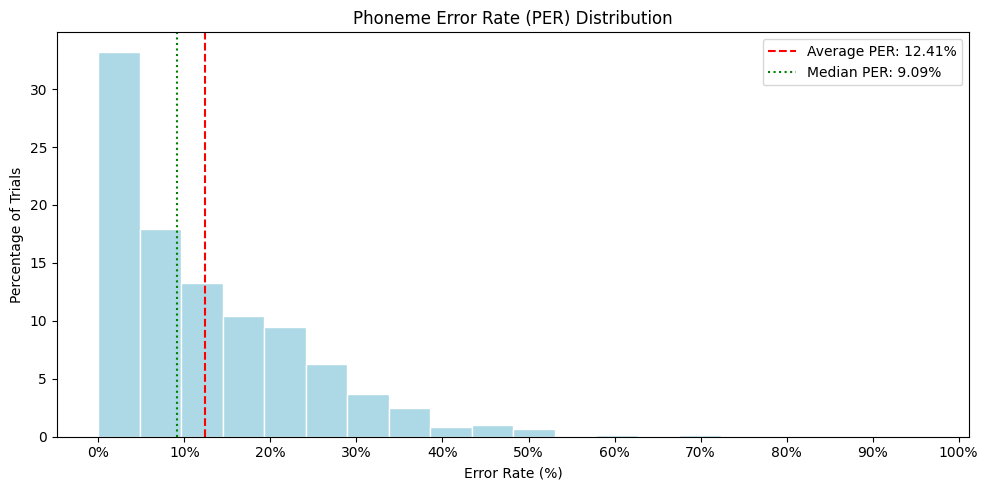

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def evaluate_with_stats(model, val_loader, device, args):
    model.eval()
    all_refs, all_hyps, all_pers = [], [], []

    k, s = args.pool_kernel, args.pool_stride

    with torch.no_grad():
        for batch_feat, batch_ids, batch_lens, input_time_steps in val_loader:
            batch_feat    = batch_feat.to(device)
            input_lengths = compute_token_lengths(
                input_time_steps, k, s).to(device)

            # Build attention mask (B, 1, 1, P)
            B, T_p = batch_feat.size(0), batch_feat.size(-1)
            P = compute_token_lengths(torch.tensor([T_p]), k, s).item()
            seq_range = torch.arange(P, device=device).expand(B, P)
            attn_mask = (seq_range < input_lengths.unsqueeze(1)).unsqueeze(1).unsqueeze(2)

            with torch.autocast(device_type=device.type, dtype=torch.float16):
                log_probs = model(batch_feat, mask=attn_mask).log_softmax(dim=-1)

            hyps = greedy_ctc_decode(log_probs)
            for i in range(len(hyps)):
                slen = int(batch_lens[i].item())
                ref  = batch_ids[i, :slen].tolist()
                hyp  = hyps[i]
                per  = phoneme_error_rate([ref], [hyp])
                all_refs.append(ref)
                all_hyps.append(hyp)
                all_pers.append(per)

    # Print sample predictions
    print(f'\n{"True Sequence":<50} | {"Predicted Sequence":<50} | PER')
    print('-' * 115)
    for ref, hyp, per in zip(all_refs[:5], all_hyps[:5], all_pers[:5]):
        ref_str = ' '.join(LOGIT_TO_PHONEME[p] for p in ref[:8] if p < NUM_PHONEMES)
        hyp_str = ' '.join(LOGIT_TO_PHONEME[p] for p in hyp[:8] if p < NUM_PHONEMES)
        print(f'{ref_str:<50} | {hyp_str:<50} | {per:.2f}%')

    # Final statistics
    pers = np.array(all_pers)
    print(f'\nFinal Statistics:')
    print(f'  Mean PER   : {pers.mean():.2f}%')
    print(f'  Median PER : {np.median(pers):.2f}%')
    print(f'  Std PER    : {pers.std():.2f}%')

    # Distribution plot
    plt.figure(figsize=(10, 5))
    plt.hist(pers, bins=20, weights=np.ones(len(pers))/len(pers)*100,
             color='lightblue', edgecolor='white')
    plt.axvline(pers.mean(),     color='red',   linestyle='--',
                label=f'Average PER: {pers.mean():.2f}%')
    plt.axvline(np.median(pers), color='green', linestyle=':',
                label=f'Median PER: {np.median(pers):.2f}%')
    plt.xlabel('Error Rate (%)')
    plt.ylabel('Percentage of Trials')
    plt.title('Phoneme Error Rate (PER) Distribution')
    plt.xticks(ticks=np.arange(0, 101, 10),
               labels=[f'{x}%' for x in range(0, 101, 10)])
    plt.legend()
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/PER_distribution.png', dpi=150)
    plt.show()

    return pers


# 加载 checkpoint 并运行
ckpt_path = '/content/drive/MyDrive/DBConformer_runs_512/NeuralPhoneme/DBConformerCTC_t15.2023.08.18_best.ckpt'
model_eval.load_state_dict(torch.load(ckpt_path, map_location=device))
model_eval.eval()
print(f'Loaded: {ckpt_path}')

# Build val loader
val_dataset = SpeechDataset(val_index, max_time_steps=args.max_time_steps)
val_sampler = BucketBatchSampler(val_dataset, batch_size=args.batch_size)
val_loader  = DataLoader(val_dataset, batch_sampler=val_sampler,
                         collate_fn=collate_fn, num_workers=2, pin_memory=True)

pers = evaluate_with_stats(model_eval, val_loader, device, args)

# uncertainty

In [ ]:
def compute_am_sequence_score(log_probs, input_lengths):
    max_log_probs = log_probs.max(dim=-1)[0]  # (T, B)
    scores = []
    for i in range(log_probs.shape[1]):
        valid_len = input_lengths[i].item()
        score = max_log_probs[:valid_len, i].mean().item()
        scores.append(-score)
    return torch.tensor(scores)

In [ ]:
def evaluate_am_uncertainty(model, data_loader, device, args):
    model.eval()
    all_pers = []
    all_am_uncertainties = []
    samples = []

    print("Running AM Uncertainty Evaluation...")
    with torch.no_grad():
        for neural_batch, phoneme_batch, seq_lens, input_time_steps in data_loader:
            neural_batch = neural_batch.to(device)

            input_lengths = compute_token_lengths(
                input_time_steps, args.pool_kernel, args.pool_stride
            ).to(device)

            log_probs = model(neural_batch).log_softmax(dim=-1)
            am_uncertainty = compute_am_sequence_score(log_probs, input_lengths)
            predictions_ids = greedy_ctc_decode(log_probs)

            for i, phoneme_ids in enumerate(predictions_ids):
                true_len = seq_lens[i].item()
                true_seq = phoneme_batch[i][:true_len].tolist()
                per = phoneme_error_rate([true_seq], [phoneme_ids]) / 100.0
                all_pers.append(per)
                all_am_uncertainties.append(am_uncertainty[i].item())

                if len(samples) < 15:
                    samples.append({
                        'am_unc': am_uncertainty[i].item(),
                        'per': per,
                        'pred': [LOGIT_TO_PHONEME[idx] for idx in phoneme_ids],
                        'true': [LOGIT_TO_PHONEME[idx] for idx in true_seq],
                    })

    # 打印样本
    print(f"\n{'AM_UNC':<10} | {'PER':<10} | {'Predicted':<40} | {'True'}")
    print("-" * 100)
    for s in samples:
        print(f"{s['am_unc']:.4f}    | {s['per']:.2%}    | "
              f"{str(s['pred'][:8]):<40} | {str(s['true'][:8])}")

    # 相관性
    corr = np.corrcoef(all_am_uncertainties, all_pers)[0, 1]
    print(f"\n--- Uncertainty 分析 ---")
    print(f"AM uncertainty vs PER 相关性: {corr:.3f}")
    print(f"平均PER: {np.mean(all_pers):.2%}")
    print(f"中位PER: {np.median(all_pers):.2%}")

    # 根据实际分布自动计算boundaries（四分位数）
    unc_array = np.array(all_am_uncertainties)
    q25, q50, q75 = np.percentile(unc_array, [25, 50, 75])
    print(f"\n--- AM置信度分层 (基于四分位数) ---")
    boundaries = [(0,    q25,  'HIGH     '),
                  (q25,  q50,  'MEDIUM   '),
                  (q50,  q75,  'LOW      '),
                  (q75,  9999, 'VERY_LOW ')]
    for lo, hi, label in boundaries:
        group_pers = [p for p, u in zip(all_pers, all_am_uncertainties) if lo <= u < hi]
        if group_pers:
            print(f"{label}: {len(group_pers):4d}个样本 ({len(group_pers)/len(all_pers):.1%}), "
                  f"平均PER={np.mean(group_pers):.2%}, 中位PER={np.median(group_pers):.2%}")

    # 可视化
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sorted_indices = np.argsort(all_am_uncertainties)
    sorted_pers = [all_pers[i] for i in sorted_indices]
    sorted_uncs = [all_am_uncertainties[i] for i in sorted_indices]
    n_bins = 10
    bin_size = len(sorted_pers) // n_bins
    bin_pers = [np.mean(sorted_pers[i*bin_size:(i+1)*bin_size]) for i in range(n_bins)]
    bin_uncs = [np.mean(sorted_uncs[i*bin_size:(i+1)*bin_size]) for i in range(n_bins)]

    axes[0].plot(bin_uncs, bin_pers, 'o-', color='red')
    axes[0].set_xlabel('AM Uncertainty')
    axes[0].set_ylabel('Average PER')
    axes[0].set_title('AM Calibration Curve')
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(all_am_uncertainties, all_pers, alpha=0.3, s=20, color='green')
    axes[1].set_xlabel('AM Uncertainty')
    axes[1].set_ylabel('PER')
    axes[1].set_title(f'AM Uncertainty vs PER (corr={corr:.3f})')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/AM_uncertainty.png', dpi=150)
    plt.show()

    return all_pers, all_am_uncertainties

Running AM Uncertainty Evaluation...

AM_UNC     | PER        | Predicted                                | True
----------------------------------------------------------------------------------------------------
0.0438    | 16.22%    | ['AO', 'R', 'T', 'N', 'IH', 'NG', '|', 'AA'] | ['OW', 'N', 'IH', 'NG', '|', 'AA', 'N', '|']
0.0650    | 31.25%    | ['W', 'EY', 'S', '|', 'B', 'P', 'AO', 'R'] | ['W', 'EY', 'V', 'Z', '|', 'B', 'AO', 'R']
0.0143    | 0.00%    | ['AY', '|', 'D', 'OW', 'N', 'T', '|', 'M'] | ['AY', '|', 'D', 'OW', 'N', 'T', '|', 'M']
0.0275    | 20.45%    | ['T', 'R', 'T', 'R', 'AH', 'P', 'S', '|'] | ['T', 'R', 'AH', 'M', 'P', 'S', '|', 'B']
0.0221    | 6.45%    | ['IH', 'T', '|', 'S', 'IY', 'M', 'Z', '|'] | ['IH', 'T', '|', 'S', 'IY', 'M', 'Z', '|']
0.0432    | 25.64%    | ['SH', 'AA', 'P', '|', 'S', 'T', 'R', 'EY'] | ['SH', 'AA', 'P', '|', 'S', 'P', 'R', 'EY']
0.0224    | 12.00%    | ['M', 'AY', '|', 'D', 'EY', 'D', '|', 'IH'] | ['M', 'AY', '|', 'D', 'AE', 'D', '|', 'IH']

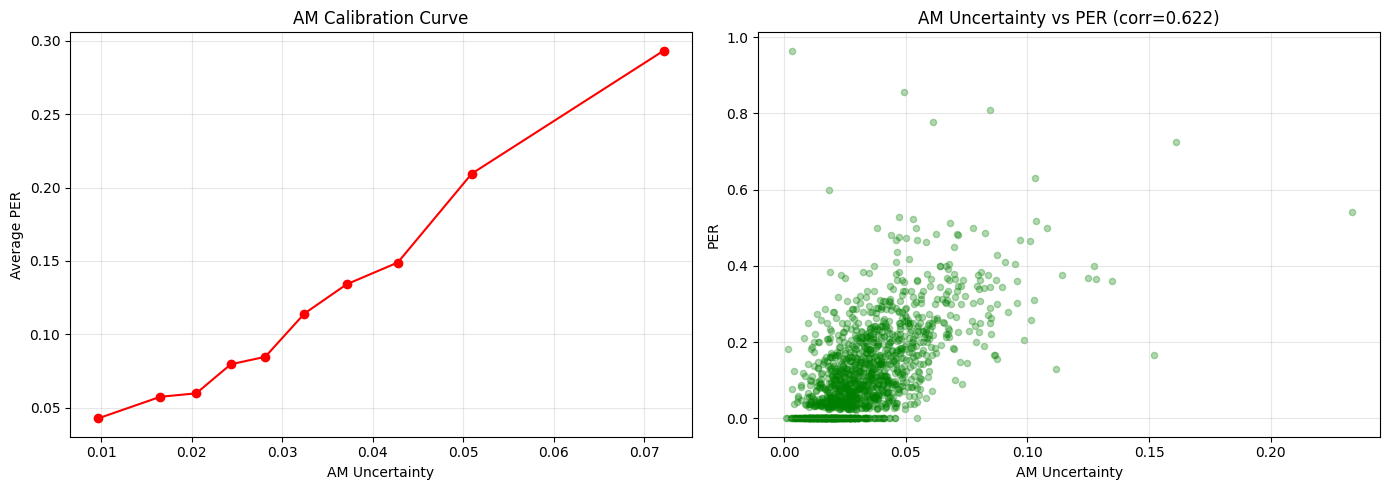

In [ ]:
all_pers, all_am_uncertainties = evaluate_am_uncertainty(model, val_loader, device, args)